# Setup

In [ ]:
%pip install xxhash pandas matplotlib numpy

In [38]:
import uuid
from random import randint, sample, shuffle
from typing import Dict, List, Optional
from abc import ABC, abstractmethod

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from anchorhash import AnchorHasher

In [39]:
class Hascher(ABC):
    @abstractmethod
    def getShard(self, record_id: str) -> int:
        pass

    @abstractmethod
    def addShard(self, shard_id: int):
        pass

    @abstractmethod
    def dropShard(self, shard_id: int):
        pass

In [40]:
class AnchorHasherAdapter(Hascher):
    def __init__(
        self, working_set: List[str], capacity: int, seed: Optional[int] = None
    ) -> None:
        self._impl = AnchorHasher(working_set, capacity=capacity, seed=seed)
        self.name = self._impl.name

    def getShard(self, record_id: str) -> int:
        return self._impl.getShard(record_id)

    def addShard(self, shard_id: int) -> None:
        self._impl.addShard(shard_id)

    def dropShard(self, shard_id: int) -> None:
        self._impl.dropShard(shard_id)

In [41]:
def generate_removal_different_places(original_order, distance):
    n = len(original_order)
    scramble_count = int(n * distance)
    map = {}

    for i in range(n):
        if i+scramble_count > n:
            break

        # Split the array into three parts
        before = original_order[:i]
        middle = original_order[i:i+scramble_count]
        after = original_order[i+scramble_count:]

        # Shuffle the middle part
        shuffle(middle)

        # Combine the parts back together
        new_order = before + middle + after

        # Save the new order in the map with the starting index as key
        map[i] = new_order
    
    return map 

def generate_records(count: int = 100000) -> List[uuid.UUID]:
    """Generate a list of random records for testing."""
    return [uuid.uuid1() for i in range(count)]

def run_single_distance_experiment(
    h_default: Hascher, h_variant: Hascher, records: List, distance: float
) -> float:
    """Run experiment for single distance value and return failure rate."""
    mismatches = 0
    for r in records:
        if h_default.getShard(str(r)) != h_variant.getShard(str(r)):
            mismatches += 1
    failure_rate = mismatches / len(records)
    print(f"distance={distance:.2f} mismatches={mismatches} rate={failure_rate:.4f}")
    return failure_rate

# Experiment

In [42]:
def run_experiment(RECORDS: List, map: Dict[int, List[int]], total_shards: int, dropped_shards: List[int]):
    indexes = sorted(map.keys())
    results = {}

    for d in indexes:
        diff_order = map[d]
        seed = randint(0, 2**32 - 1)

        # Create hasher instances
        h_default = AnchorHasherAdapter(
            [str(i) for i in range(total_shards)], capacity=total_shards, seed=seed
        )
        h_variant = AnchorHasherAdapter(
            [str(i) for i in range(total_shards)], capacity=total_shards, seed=seed
        )
        # Apply removals
        for s in reversed(dropped_shards):
            h_default.dropShard(s)
        for s in reversed(diff_order):
            h_variant.dropShard(s)

        # Calculate and store failure rate
        failure_rate = run_single_distance_experiment(
            h_default, h_variant, RECORDS, d
        )
        
        results[d] = {
            "index": d,
            "failure_rates": failure_rate,
            "dropped_shards": dropped_shards,
        }
    return results

In [44]:
def run_single_size(RECORDS: List, total_shards: int, drop_shards_cnt: int):
    results = {}

    for i in [0.9]:
        dropped_shards = sample(range(total_shards), drop_shards_cnt)

        map = generate_removal_different_places(dropped_shards, i)
        result = run_experiment(RECORDS, map, total_shards, dropped_shards)
        results[i] = result
    
    return results

distance=0.00 mismatches=22657 rate=0.2266
distance=1.00 mismatches=22824 rate=0.2282
distance=2.00 mismatches=22753 rate=0.2275
distance=3.00 mismatches=23099 rate=0.2310
distance=4.00 mismatches=22801 rate=0.2280
distance=5.00 mismatches=22762 rate=0.2276
distance=6.00 mismatches=23012 rate=0.2301
distance=7.00 mismatches=22739 rate=0.2274
distance=8.00 mismatches=22777 rate=0.2278
distance=9.00 mismatches=22674 rate=0.2267
distance=10.00 mismatches=22852 rate=0.2285
distance=11.00 mismatches=22978 rate=0.2298
distance=12.00 mismatches=23053 rate=0.2305
distance=13.00 mismatches=22912 rate=0.2291
distance=14.00 mismatches=22678 rate=0.2268
distance=15.00 mismatches=22730 rate=0.2273
distance=16.00 mismatches=22963 rate=0.2296
distance=17.00 mismatches=22766 rate=0.2277
distance=18.00 mismatches=22854 rate=0.2285
distance=19.00 mismatches=22867 rate=0.2287
distance=20.00 mismatches=22937 rate=0.2294
distance=21.00 mismatches=22984 rate=0.2298
distance=22.00 mismatches=22906 rate=0.229

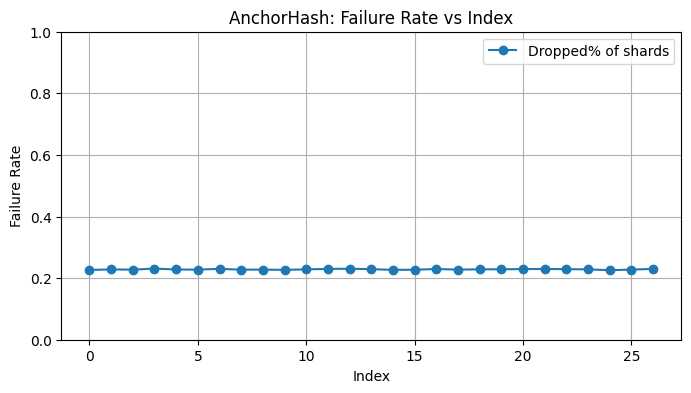

{0.9: {0: {'index': 0, 'failure_rates': 0.46897, 'dropped_shards': [498, 1013, 540, 326, 0, 71, 879, 502, 488, 545, 730, 644, 363, 95, 775, 763, 707, 90, 848, 569, 12, 555, 73, 275, 192, 925, 146, 456, 888, 480, 384, 865, 1010, 300, 609, 170, 270, 556, 219, 686, 551, 385, 426, 610, 845, 469, 293, 278, 117, 947, 429, 11, 174, 670, 912, 589, 228, 276, 313, 991, 941, 309, 923, 989, 185, 66, 268, 809, 557, 655, 126, 946, 543, 693, 379, 22, 708, 714, 764, 47, 241, 163, 883, 143, 348, 265, 44, 437, 210, 246, 399, 508, 173, 302, 132, 396, 359, 940, 752, 572, 711, 427, 7, 380, 301, 640, 606, 671, 728, 466, 204, 841, 995, 603, 774, 757, 665, 252, 868, 546, 688, 706, 452, 159, 523, 886, 924, 428, 641, 49, 903, 767, 21, 967, 593, 751, 91, 645, 42, 470, 738, 213, 1016, 893, 709, 88, 233, 51, 257, 111, 285, 286, 124, 212, 565, 541, 494, 355, 929, 94, 9, 260, 261, 746, 97, 628, 289, 920, 214, 31, 659, 122, 721, 744, 367, 682, 468, 54, 395, 872, 349, 319, 623, 39, 810, 447, 831, 880, 687, 484, 617, 9

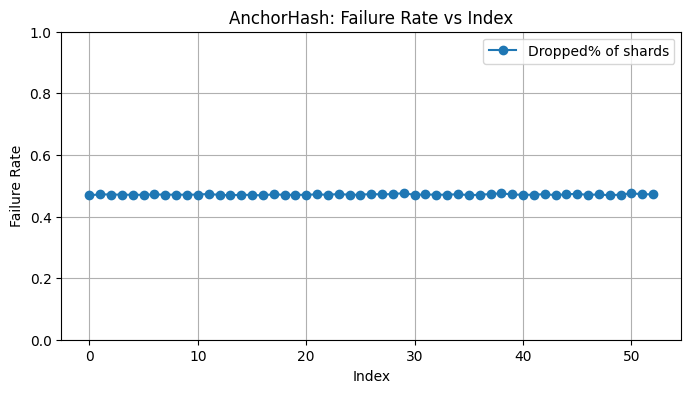

{0.9: {0: {'index': 0, 'failure_rates': 0.72623, 'dropped_shards': [842, 526, 719, 627, 836, 796, 541, 426, 227, 598, 859, 104, 190, 254, 696, 135, 112, 452, 731, 423, 530, 912, 661, 656, 579, 559, 730, 578, 928, 610, 404, 767, 179, 776, 501, 986, 131, 580, 206, 29, 623, 910, 8, 0, 105, 301, 704, 634, 849, 447, 782, 669, 508, 128, 325, 201, 815, 657, 264, 533, 266, 630, 188, 673, 688, 626, 649, 505, 901, 593, 547, 675, 6, 145, 15, 966, 679, 427, 999, 648, 572, 585, 161, 891, 554, 867, 481, 143, 678, 810, 17, 792, 67, 376, 577, 844, 676, 532, 205, 230, 659, 391, 898, 195, 694, 671, 918, 555, 56, 292, 408, 304, 146, 416, 655, 280, 295, 691, 46, 221, 771, 825, 646, 582, 297, 117, 61, 1001, 990, 717, 298, 1017, 64, 988, 316, 456, 149, 899, 937, 438, 170, 306, 134, 293, 507, 402, 592, 962, 23, 269, 805, 303, 607, 1002, 816, 779, 781, 958, 773, 488, 274, 25, 330, 1, 591, 594, 379, 595, 318, 752, 975, 213, 628, 375, 392, 413, 91, 706, 267, 833, 49, 939, 878, 625, 770, 1014, 492, 496, 943, 177

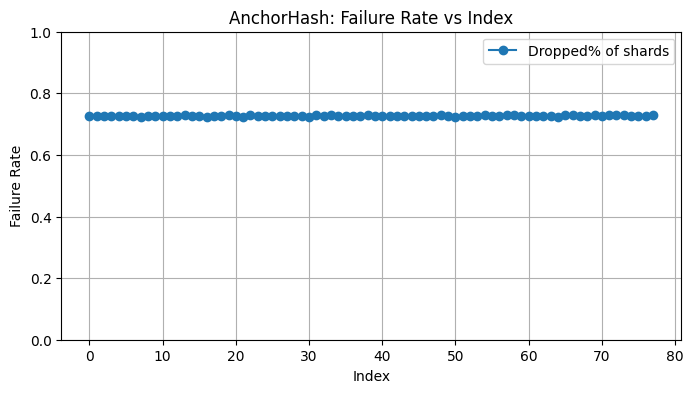

In [ ]:
RECORDS = generate_records(100000)

total_shards = 1024
results = {}

for i in [0.25, 0.5, 0.75]:
    drop_shards_cnt = int(total_shards * i)
    results[i] = run_single_size(RECORDS, total_shards, drop_shards_cnt)

print(results)

# Plot the results
for n, res in results.items():
    for i, fig in res.items():
        plt.figure(figsize=(8, 4))
        # Extract data for plotting
        distances = [result["index"] for result in fig.values()]
        failure_rates = [result["failure_rates"] for result in fig.values()]

        plt.plot(
            distances,
            failure_rates,
            marker="o",
            label=f"Dropped {n*100:.0f}% of shards",
        )

    plt.xlabel("Index")
    plt.ylabel("Failure Rate")
    plt.title("AnchorHash: Failure Rate vs Index")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()